In [1]:
from glob import glob
import os
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import pickle as pkl


### Cross-decoding prior

In [2]:
files = glob('../data/generated/temporal_prior/*.pqt')

In [3]:
from manifold.plot_decoders import load_data,plot_prior


df_prior = load_data('../data/generated/temporal_prior/*.pqt')

In [4]:
def aggregate_prior_all_trials(df, region='VISp'):
    """Aggregates prior decoders data"""
    time_cols = [c for c in df.columns if c.startswith('logreg_prob_f')]
    
    id_vars = [
        'session_id', 'original_trial_index', 'region', 
        'is_correct_trial', 'is_congruent', 'prior',
        'signed_contrast', 'choice','probabilityLeft'
    ]
    df_sub = df[id_vars + time_cols].copy()
    
    # Filter out unbiased blocks
    df_sub = df_sub[df_sub['probabilityLeft'] != 0.5].copy()
    
    # Filter for region
    df_sub = df_sub[df_sub['region'] == region].copy()
    
    df_sub['condition'] = np.where(df_sub['is_correct_trial'], 'Correct', 'Error')
    
    melt_ids = [
        'session_id', 'original_trial_index', 'region', 'condition', 
        'is_congruent', 'prior', 'signed_contrast', 'choice','probabilityLeft'
    ]
    
    df_melt = df_sub.melt(id_vars=melt_ids, 
                          value_vars=time_cols, 
                          var_name='frame', value_name='prob')
                          
    df_melt['time'] = df_melt['frame'].str.extract(r'f(-?\d+)').astype(int)
    
    # Align probabilities back to True Block
    df_melt['true_block'] = np.where(df_melt['prior'] > 0.5, 1, -1)
    df_melt['aligned_prob'] = np.where(df_melt['true_block'] == 1, df_melt['prob'], 1 - df_melt['prob'])
    
    return df_melt

In [5]:
df_melt_visp = aggregate_prior_all_trials(df_prior)

Text(0.5, 0.98, 'VISp')

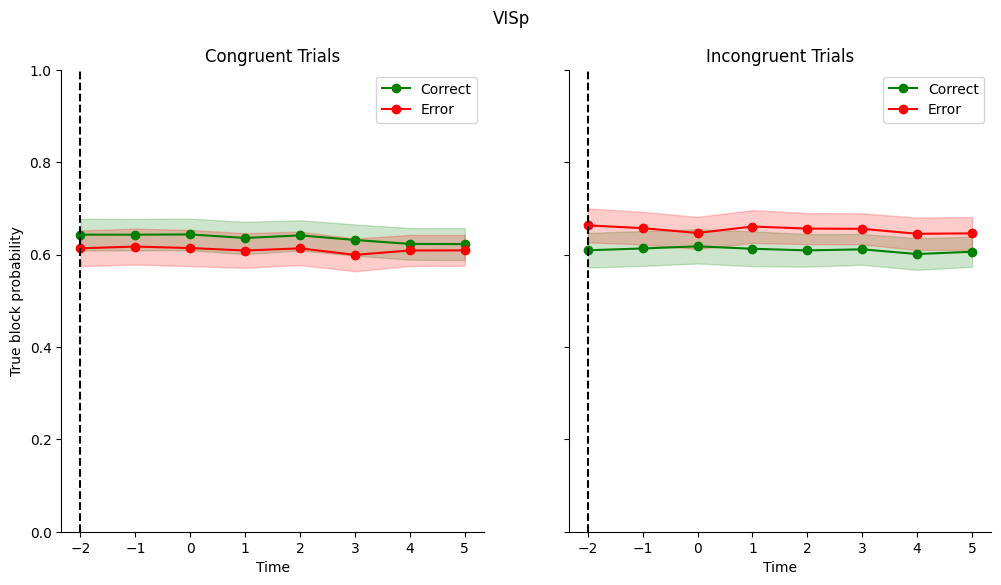

In [8]:

df_melt_visp = aggregate_prior_all_trials(df_prior)
df_session_avg = df_melt_visp.groupby(['session_id', 'region', 'condition', 'time','is_congruent'])['aligned_prob'].mean().reset_index()
palette = {'Correct': 'green', 'Error': 'red'}
fig, ax = plt.subplots(figsize=(12,6), ncols=2, sharey=True)

for i, congruent in enumerate([True, False]):

    df_plot = df_session_avg[df_session_avg['is_congruent'] == congruent]

    for condition in ['Correct', 'Error']:
        df_cond = df_plot[df_plot['condition'] == condition]

        stats = (
            df_cond
            .groupby('time')['aligned_prob']
            .agg(['mean', 'sem'])
            .reset_index()
        )

        ax[i].plot(
            stats['time'],
            stats['mean'],
            color=palette[condition],
            marker='o',
            label=condition
        )

        ax[i].fill_between(
            stats['time'],
            stats['mean'] - stats['sem'],
            stats['mean'] + stats['sem'],
            color=palette[condition],
            alpha=0.2
        )

    ax[i].set_title(
        'Congruent Trials' if congruent else 'Incongruent Trials'
    )

    ax[i].axvline(-2, color='k', linestyle='--')

ax[0].set_ylim(0, 1)
ax[0].set_ylabel('True block probability')

for a in ax:
    a.set_xlabel('Time')
    a.legend()

sns.despine()
plt.suptitle('VISp')

Text(0.5, 0.98, 'MOs')

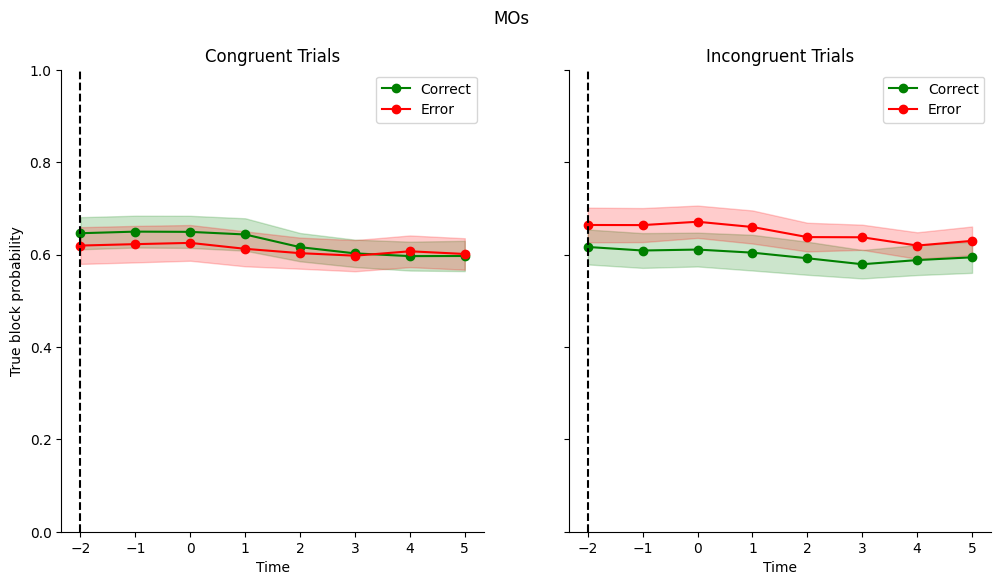

In [9]:

df_melt_mos = aggregate_prior_all_trials(df_prior,'MOs')
df_session_avg = df_melt_mos.groupby(['session_id', 'region', 'condition', 'time','is_congruent'])['aligned_prob'].mean().reset_index()
palette = {'Correct': 'green', 'Error': 'red'}
fig, ax = plt.subplots(figsize=(12,6), ncols=2, sharey=True)

for i, congruent in enumerate([True, False]):

    df_plot = df_session_avg[df_session_avg['is_congruent'] == congruent]

    for condition in ['Correct', 'Error']:
        df_cond = df_plot[df_plot['condition'] == condition]

        stats = (
            df_cond
            .groupby('time')['aligned_prob']
            .agg(['mean', 'sem'])
            .reset_index()
        )

        ax[i].plot(
            stats['time'],
            stats['mean'],
            color=palette[condition],
            marker='o',
            label=condition
        )

        ax[i].fill_between(
            stats['time'],
            stats['mean'] - stats['sem'],
            stats['mean'] + stats['sem'],
            color=palette[condition],
            alpha=0.2
        )

    ax[i].set_title(
        'Congruent Trials' if congruent else 'Incongruent Trials'
    )

    ax[i].axvline(-2, color='k', linestyle='--')

ax[0].set_ylim(0, 1)
ax[0].set_ylabel('True block probability')

for a in ax:
    a.set_xlabel('Time')
    a.legend()

sns.despine()
plt.suptitle('MOs')

,session_id,original_trial_index,region,condition,is_congruent,prior,signed_contrast,choice,probabilityLeft,frame,prob,time,true_block,aligned_prob
0,2864dca1-38d8-464c-9777-f6fdfd5e63b5,90,MOs,Correct,True,0.305916,-0.2500,-1.0,0.2,logreg_prob_f-2,0.011063,-2,-1,0.988937
1,2864dca1-38d8-464c-9777-f6fdfd5e63b5,93,MOs,Correct,True,0.591327,-0.1250,-1.0,0.2,logreg_prob_f-2,0.484491,-2,1,0.484491
2,2864dca1-38d8-464c-9777-f6fdfd5e63b5,94,MOs,Correct,True,0.428483,-0.0625,-1.0,0.2,logreg_prob_f-2,0.418856,-2,-1,0.581144
3,2864dca1-38d8-464c-9777-f6fdfd5e63b5,100,MOs,Correct,True,0.406170,-0.0625,-1.0,0.2,logreg_prob_f-2,0.562902,-2,-1,0.437098
4,2864dca1-38d8-464c-9777-f6fdfd5e63b5,102,MOs,Correct,False,0.488652,0.1250,1.0,0.2,logreg_prob_f-2,0.096803,-2,-1,0.903197
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56907,f7d46a15-9498-40dc-90da-fb977ce844be,939,MOs,Error,False,0.550783,0.0625,-1.0,0.2,logreg_prob_f5,0.968207,5,1,0.968207
56908,f7d46a15-9498-40dc-90da-fb977ce844be,950,MOs,Error,True,0.471531,-0.0625,1.0,0.2,logreg_prob_f5,0.944162,5,-1,0.055838
56909,f7d46a15-9498-40dc-90da-fb977ce844be,953,MOs,Error,True,0.769806,-0.1250,1.0,0.2,logreg_prob_f5,0.968077,5,1,0.968077
56910,f7d46a15-9498-40dc-90da-fb977ce844be,954,MOs,Error,True,0.825504,-0.0625,1.0,0.2,logreg_prob_f5,0.897731,5,1,0.897731


In [24]:
df_inc = df_melt_visp[df_melt_visp['is_congruent'] == False].dropna(subset=['aligned_prob', 'condition', 'session_id'])
df_c = df_melt_visp[df_melt_visp['is_congruent'] == True].dropna(subset=['aligned_prob', 'condition', 'session_id'])

In [20]:
import statsmodels.formula.api as smf
model = smf.mixedlm("aligned_prob ~ C(condition)", data=df_inc, groups=df_inc["session_id"])
result = model.fit()

In [23]:
print(result.summary())

             Mixed Linear Model Regression Results
Model:               MixedLM  Dependent Variable:  aligned_prob
No. Observations:    11088    Method:              REML        
No. Groups:          15       Scale:               0.0744      
Min. group size:     272      Log-Likelihood:      -1369.8982  
Max. group size:     1152     Converged:           Yes         
Mean group size:     739.2                                     
---------------------------------------------------------------
                      Coef. Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept             0.610    0.034 17.786 0.000  0.543  0.677
C(condition)[T.Error] 0.050    0.006  8.898 0.000  0.039  0.061
Group Var             0.017    0.025                           



In [25]:
import statsmodels.formula.api as smf
model = smf.mixedlm("aligned_prob ~ C(condition)", data=df_c, groups=df_c["session_id"])
result = model.fit()
print(result.summary())

             Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   aligned_prob
No. Observations:   45824     Method:               REML        
No. Groups:         15        Scale:                0.0749      
Min. group size:    1352      Log-Likelihood:       -5696.5192  
Max. group size:    4704      Converged:            Yes         
Mean group size:    3054.9                                      
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept              0.635    0.034 18.943 0.000  0.570  0.701
C(condition)[T.Error] -0.024    0.004 -6.827 0.000 -0.031 -0.017
Group Var              0.017    0.023                           



In [ ]:
# import bambi as bmb
# import arviz as az
# bayesian_model = bmb.Model("aligned_prob ~ condition + (1 | session_id)", df_inc)

# # 3. Fit the model using MCMC sampling
# idata = bayesian_model.fit(draws=2000, tune=1000, target_accept=0.9)

# # 4. Summarize the posterior distributions
# summary_df = az.summary(idata)
# print(summary_df)

# # Plot the posterior for the condition effect

# az.plot_posterior(idata, var_names=["condition"])

,session_id,original_trial_index,region,condition,is_congruent,prior,signed_contrast,choice,probabilityLeft,frame,prob,time,true_block,aligned_prob
0,2864dca1-38d8-464c-9777-f6fdfd5e63b5,90,VISp,Correct,True,0.305916,-0.2500,-1.0,0.2,logreg_prob_f-2,0.486116,-2,-1,0.513884
1,2864dca1-38d8-464c-9777-f6fdfd5e63b5,93,VISp,Correct,True,0.591327,-0.1250,-1.0,0.2,logreg_prob_f-2,0.553828,-2,1,0.553828
2,2864dca1-38d8-464c-9777-f6fdfd5e63b5,94,VISp,Correct,True,0.428483,-0.0625,-1.0,0.2,logreg_prob_f-2,0.289325,-2,-1,0.710675
3,2864dca1-38d8-464c-9777-f6fdfd5e63b5,100,VISp,Correct,True,0.406170,-0.0625,-1.0,0.2,logreg_prob_f-2,0.436241,-2,-1,0.563759
5,2864dca1-38d8-464c-9777-f6fdfd5e63b5,104,VISp,Correct,True,0.731509,-0.1250,-1.0,0.2,logreg_prob_f-2,0.565911,-2,1,0.565911
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56906,f7d46a15-9498-40dc-90da-fb977ce844be,910,VISp,Error,True,0.435180,0.2500,-1.0,0.8,logreg_prob_f5,0.941532,5,-1,0.058468
56908,f7d46a15-9498-40dc-90da-fb977ce844be,950,VISp,Error,True,0.471531,-0.0625,1.0,0.2,logreg_prob_f5,0.844947,5,-1,0.155053
56909,f7d46a15-9498-40dc-90da-fb977ce844be,953,VISp,Error,True,0.769806,-0.1250,1.0,0.2,logreg_prob_f5,0.868917,5,1,0.868917
56910,f7d46a15-9498-40dc-90da-fb977ce844be,954,VISp,Error,True,0.825504,-0.0625,1.0,0.2,logreg_prob_f5,0.817974,5,1,0.817974
